In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Heart_dataset - Heart_dataset.csv")
df.describe()


,Unnamed: 0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,302.000000,303.000000,302.000000,302.000000,301.000000,302.000000,303.000000,302.000000,299.000000
mean,152.000000,54.438944,0.679868,131.662252,246.693069,0.149007,0.986755,149.674419,0.324503,1.039604,1.602649,0.672241
std,87.612784,9.038662,0.467299,17.622429,51.776918,0.356686,0.994916,22.762549,0.468966,1.161075,0.616274,0.937438
min,1.000000,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,76.500000,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,134.000000,0.000000,0.000000,1.000000,0.000000
50%,152.000000,56.000000,1.000000,130.000000,241.000000,0.000000,0.500000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,227.500000,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,303.000000,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [93]:
df.shape

(303, 15)

In [94]:
print(df.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs',
       'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD'],
      dtype='str')


In [95]:

df = df.drop("Unnamed: 0",axis = 1)
df.head()


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145.0,233,1.0,2.0,150.0,0.0,2.3,3.0,0.0,fixed,No
1,67,1,asymptomatic,160.0,286,0.0,2.0,108.0,1.0,1.5,2.0,3.0,normal,Yes
2,67,1,asymptomatic,120.0,229,0.0,2.0,129.0,1.0,2.6,2.0,2.0,reversable,Yes
3,37,1,nonanginal,130.0,250,0.0,0.0,187.0,0.0,3.5,3.0,0.0,normal,No
4,41,0,nontypical,130.0,204,0.0,2.0,172.0,0.0,1.4,1.0,0.0,normal,No


In [96]:
df.duplicated()
print(df.duplicated().sum())


0


In [97]:
df.isna().sum()

Age          0
Sex          0
ChestPain    0
RestBP       1
Chol         0
Fbs          1
RestECG      1
MaxHR        2
ExAng        1
Oldpeak      0
Slope        1
Ca           4
Thal         2
AHD          0
dtype: int64

In [98]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='str').columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum()

Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           0
Thal         0
AHD          0
dtype: int64

In [99]:
df.describe()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,131.656766,246.693069,0.148515,0.985149,149.696370,0.323432,1.039604,1.603960,0.663366
std,9.038662,0.467299,17.593488,51.776918,0.356198,0.993661,22.688655,0.468560,1.161075,0.615676,0.934375
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,135.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,0.500000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,165.500000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [100]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['AHD'] = le.fit_transform(df['AHD'])
print(df.head())

   Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  Oldpeak  \
0   63    1       typical   145.0   233  1.0      2.0  150.0    0.0      2.3   
1   67    1  asymptomatic   160.0   286  0.0      2.0  108.0    1.0      1.5   
2   67    1  asymptomatic   120.0   229  0.0      2.0  129.0    1.0      2.6   
3   37    1    nonanginal   130.0   250  0.0      0.0  187.0    0.0      3.5   
4   41    0    nontypical   130.0   204  0.0      2.0  172.0    0.0      1.4   

   Slope   Ca        Thal  AHD  
0    3.0  0.0       fixed    0  
1    2.0  3.0      normal    1  
2    2.0  2.0  reversable    1  
3    3.0  0.0      normal    0  
4    1.0  0.0      normal    0  


In [101]:
df = pd.get_dummies(
    df,
    columns=['ChestPain', 'Thal'],
    drop_first=True
)


print(df.head())

   Age  Sex  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  Oldpeak  Slope   Ca  \
0   63    1   145.0   233  1.0      2.0  150.0    0.0      2.3    3.0  0.0   
1   67    1   160.0   286  0.0      2.0  108.0    1.0      1.5    2.0  3.0   
2   67    1   120.0   229  0.0      2.0  129.0    1.0      2.6    2.0  2.0   
3   37    1   130.0   250  0.0      0.0  187.0    0.0      3.5    3.0  0.0   
4   41    0   130.0   204  0.0      2.0  172.0    0.0      1.4    1.0  0.0   

   AHD  ChestPain_nonanginal  ChestPain_nontypical  ChestPain_typical  \
0    0                 False                 False               True   
1    1                 False                 False              False   
2    1                 False                 False              False   
3    0                  True                 False              False   
4    0                 False                  True              False   

   Thal_normal  Thal_reversable  
0        False            False  
1         True          

In [102]:
df = df.astype(int)

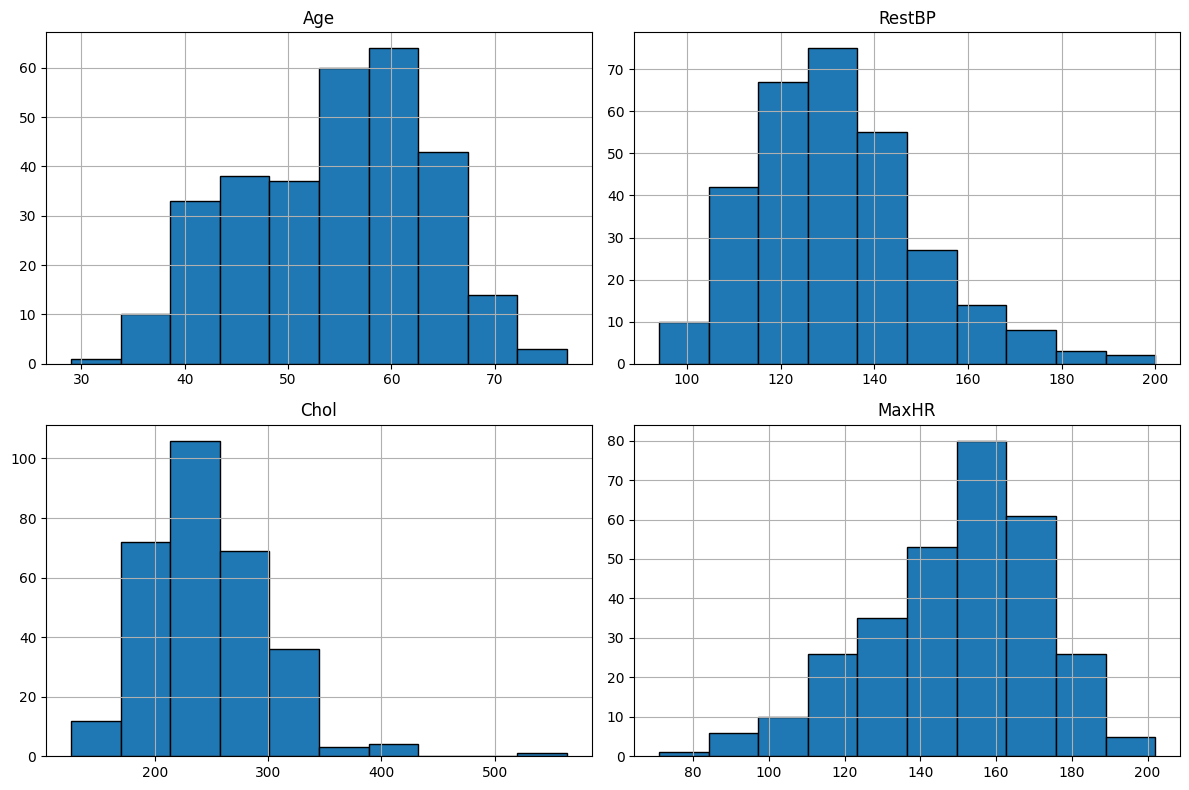

In [103]:
df[['Age', 'RestBP', 'Chol', 'MaxHR']].hist(
    figsize=(12,8),
    bins=10,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

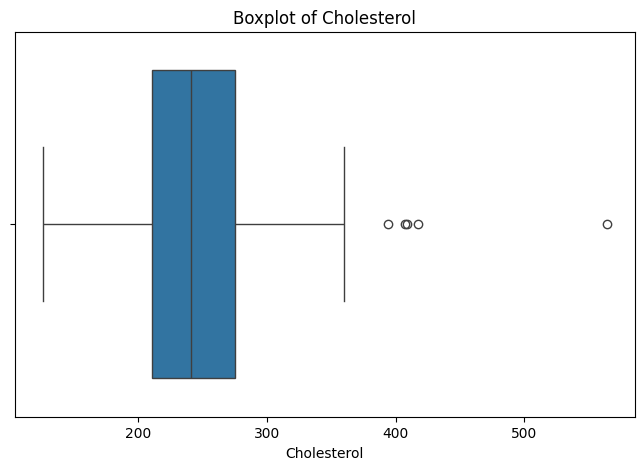

In [104]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Chol'])

plt.title('Boxplot of Cholesterol')
plt.xlabel('Cholesterol')

plt.show()

In [105]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["RestBP", "Age", "Chol", "MaxHR"]] = scaler.fit_transform(
    df[["RestBP", "Age", "Chol", "MaxHR"]]
)

df.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
0,0.948726,1,0.759674,-0.264900,1,2,0.013405,0,2,3,0,0,0,0,1,0,0
1,1.392002,1,1.613672,0.760415,0,2,-1.840803,1,1,2,3,1,0,0,0,1,0
2,1.392002,1,-0.663657,-0.342283,0,2,-0.913699,1,2,2,2,1,0,0,0,0,1
3,-1.932564,1,-0.094325,0.063974,0,0,1.646873,0,3,3,0,0,1,0,0,1,0
4,-1.489288,0,-0.094325,-0.825922,0,2,0.984656,0,1,1,0,0,0,1,0,1,0


<Axes: xlabel='Sex', ylabel='count'>

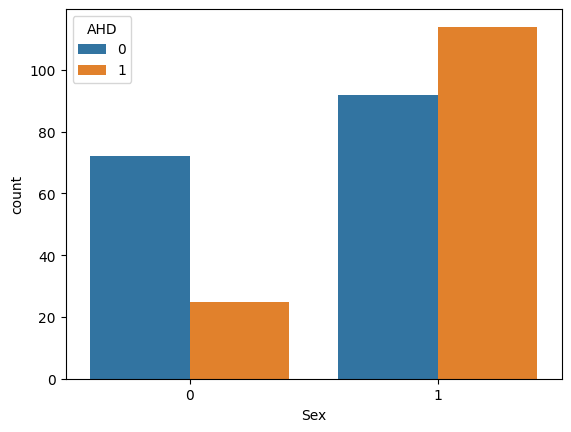

In [106]:
sns.countplot(x="Sex", hue="AHD", data=df)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)



scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ------------------------------------------------
# 9. Histograms
# ------------------------------------------------

df[['Age', 'RestBP', 'Chol', 'MaxHR']].hist(
    figsize=(12,8),
    bins=10,
    edgecolor='black'
)

plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 10. Boxplots
# ------------------------------------------------

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[['Age', 'RestBP', 'Chol', 'MaxHR', 'Oldpeak']]
)

plt.title("Boxplot of Numerical Features")
plt.show()


# ------------------------------------------------
# 11. Correlation Heatmap
# ------------------------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()